
# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Build an Interactive Retail Sales Dashboard

### Scenario

You have just joined the analytics team of **UrbanCart**, a mid-sized retail chain with stores across
three regions. Regional managers currently receive a static monthly PDF report and complain that:

1. They can't drill into *why* a number moved without emailing the analytics team.
2. Comparing stores or products side by side means flipping between many separate PDF pages.
3. Spotting a sudden dip in a specific product/store is slow and easy to miss.

**Your job:** apply the interaction techniques from the lecture — dynamic queries, coordinated views
& brushing, table lens, focus+context drill-down, and single-screen dashboard design — to build an
**interactive exploration tool** that solves these three complaints.

### How this notebook is organized

- A sample dataset is generated for you (Task 0) — don't skip running it.
- Each task states the **real-world usage**: which complaint above it solves, and why the technique
  fits.
- Tasks give you a **scaffold** (imports, helper stubs, expected output) — **you write the core logic**
  marked with `# TODO`. Do not just copy the Demo notebook's code verbatim — the data shape, column
  names and the exact question being asked are different here, so you will need to adapt the pattern,
  not paste it.


> **Grading-relevant tip:** every `# TODO` cell tells you what the final variable/plot must be named
> or show — read it before coding, since later cells depend on it.



## Task 0 — Load the Sample Dataset (provided)

Run the cells below as-is. This generates `sales_df`: 24 months of daily-aggregated sales across
6 stores (3 regions), 10 products (4 categories), including revenue, profit and customer ratings —
enough structure to support every technique you'll build below.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox

sns.set_theme(style="whitegrid")
np.random.seed(7)
print("Libraries loaded.")


Libraries loaded.


In [2]:

# --- Sample dataset generator: UrbanCart retail sales (provided, do not need to modify) ---
stores = pd.DataFrame({
    "store_id":   ["S01", "S02", "S03", "S04", "S05", "S06"],
    "store_city": ["Bengaluru", "Mysuru", "Mumbai", "Pune", "Delhi", "Jaipur"],
    "region":     ["South", "South", "West", "West", "North", "North"],
})

products = pd.DataFrame({
    "product":  ["Wireless Earbuds", "Smartwatch", "Laptop Sleeve", "USB-C Hub",
                 "Yoga Mat", "Dumbbell Set", "Running Shoes", "Track Jacket",
                 "Air Fryer", "Blender"],
    "category": ["Electronics", "Electronics", "Electronics", "Electronics",
                 "Fitness", "Fitness", "Apparel", "Apparel",
                 "Home", "Home"],
    "unit_price": [1499, 4999, 899, 1299, 799, 2499, 3499, 1999, 3999, 2299],
})

months = pd.date_range("2023-01-01", periods=24, freq="MS")

rows = []
for _, s in stores.iterrows():
    store_scale = np.random.uniform(0.7, 1.4)          # some stores just sell more
    for _, p in products.iterrows():
        product_scale = np.random.uniform(0.6, 1.6)
        trend = np.random.normal(0.01, 0.01)             # slow month-over-month growth/decline
        for i, m in enumerate(months):
            seasonal = 1 + 0.25 * np.sin(2 * np.pi * (m.month / 12))   # yearly seasonality
            units = max(0, np.random.poisson(15 * store_scale * product_scale * seasonal * (1 + trend) ** i))
            revenue = units * p["unit_price"]
            profit_margin = np.random.uniform(0.12, 0.35)
            profit = revenue * profit_margin
            rating = np.clip(np.random.normal(4.1, 0.4), 1, 5)
            # NOTE: use bracket indexing (p["product"]), not p.product -- pandas Series already has
            # a built-in .product() method, so attribute access on a column literally named "product"
            # silently returns that method instead of your data. This is a common real-world gotcha.
            rows.append((m, s["store_id"], s["store_city"], s["region"], p["product"], p["category"],
                         p["unit_price"], units, revenue, profit, round(rating, 1)))

sales_df = pd.DataFrame(rows, columns=[
    "month", "store_id", "store_city", "region", "product", "category",
    "unit_price", "units_sold", "revenue", "profit", "avg_rating"
])
for _col in ["units_sold", "revenue", "profit"]:
    sales_df[_col] = sales_df[_col].astype(float)  # float, so the anomaly injection below can scale them

# Inject one deliberate "anomaly" for Task 4 (a real dip a manager would want to investigate)
mask = (sales_df.store_id == "S03") & (sales_df["product"] == "Smartwatch") & (sales_df.month == "2024-06-01")
sales_df.loc[mask, ["units_sold", "revenue", "profit"]] = sales_df.loc[mask, ["units_sold", "revenue", "profit"]] * 0.15

print(sales_df.shape)
sales_df.head()


(1440, 11)


,month,store_id,store_city,region,product,category,unit_price,units_sold,revenue,profit,avg_rating
0,2023-01-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,17.0,25483.0,4631.305022,3.9
1,2023-02-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,19.0,28481.0,8682.717042,3.8
2,2023-03-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,16.0,23984.0,8014.910391,4.0
3,2023-04-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,31.0,46469.0,11438.468953,4.8
4,2023-05-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,22.0,32978.0,5511.128059,4.2



**Reflection (answer in a sentence or two, in this markdown cell):**
Before writing any code, look at the columns above. Which columns would you use as *filters* for
dynamic querying, and which would you use to *link* views together for brushing? Write your answer
here.

For dynamic querying, region, category, store_city, and month (or date ranges) serve as ideal categorical/temporal filters to isolate specific subsets of data. For linking views via brushing, store_id (or store_city), product, and month are the primary keys to connect aggregated views (such as monthly revenue trends) to granular product/store breakdowns.



## Task 1 — Static vs. Interactive: Which Report Actually Answers the Manager's Question?

**Real-world usage:** Complaint #1 ("flipping through PDF pages"). A regional manager asks:
*"Show me total revenue by product, and let me check exactly how much any bar is worth without
squinting at a printed axis."*

**Why this technique:** A static bar chart is fine for the *headline* number, but it can't answer a
precise follow-up question live — that needs a hover-enabled interactive chart (Slide 4-8).

### Your task
1. Build a **static** `matplotlib`/`seaborn` bar chart of total revenue per `product`, sorted
   descending.
2. Build the **same** chart as an **interactive** `plotly` bar chart where hovering shows the exact
   revenue figure and the category of that product.
3. In the markdown cell below, state in 1-2 sentences: for *this specific* manager request, which
   version wins, and why (tie your answer to target-audience / data-story / ROI from the slide).


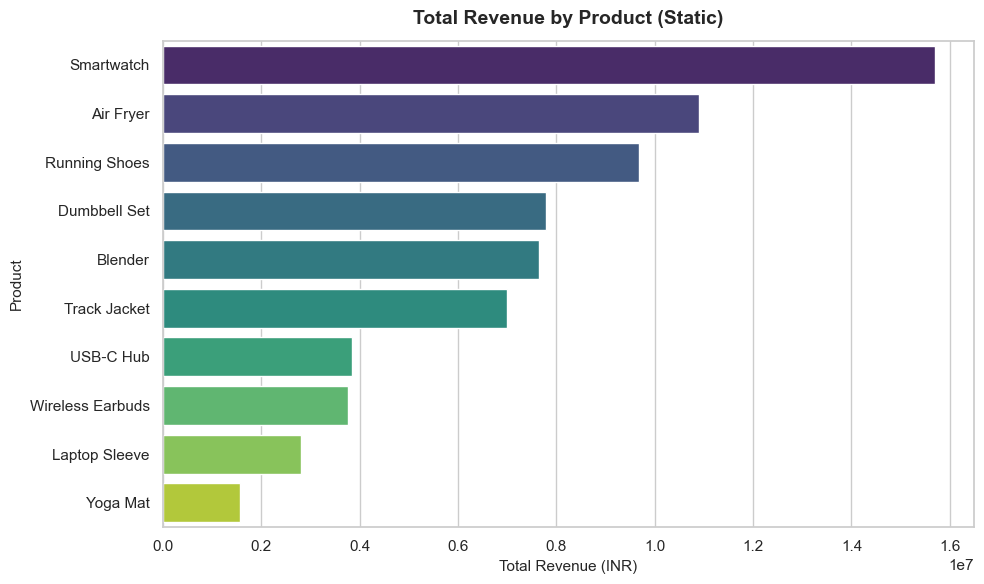

In [4]:

# --- 1a. STATIC chart ---
# TODO:
#   - Group sales_df by "product", sum "revenue"
#   - Sort descending
#   - Plot a horizontal or vertical bar chart with matplotlib/seaborn
#   - Title it clearly

# revenue_by_product = None  # TODO: replace with your groupby().sum() result, sorted

# TODO: plotting code here

revenue_by_product = (
    sales_df.groupby(["product", "category"], as_index=False)["revenue"]
    .sum()
    .sort_values(by="revenue", ascending=False)
)

# Plotting static seaborn bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=revenue_by_product,
    x="revenue",
    y="product",
    palette="viridis",
    hue="product",
    legend=False,
)
plt.title(
    "Total Revenue by Product (Static)", fontsize=14, fontweight="bold", pad=12
)
plt.xlabel("Total Revenue (INR)", fontsize=11)
plt.ylabel("Product", fontsize=11)
plt.tight_layout()
plt.show()



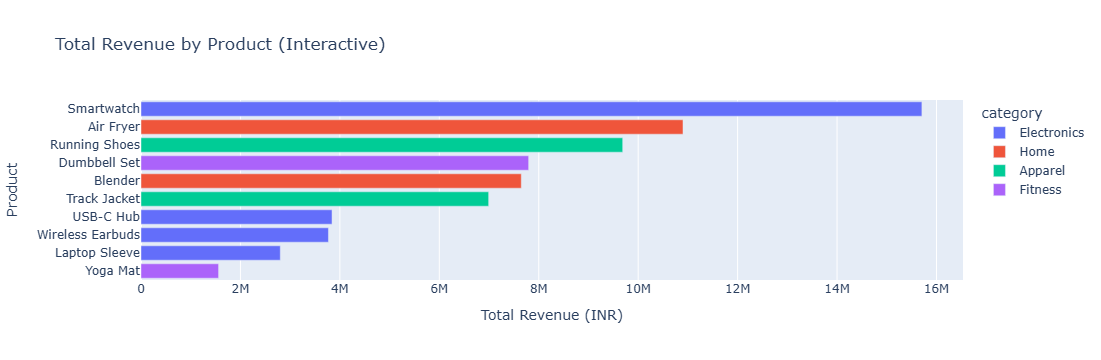

In [5]:

# --- 1b. INTERACTIVE chart ---
# TODO:
#   - Use plotly.express.bar on the SAME grouped data
#   - Add a hover field for "category" (hint: you'll need category alongside revenue -- think about
#     what columns your groupby needs to keep)
#   - Title it clearly

# TODO: plotting code here
fig_1b = px.bar(
    revenue_by_product,
    x="revenue",
    y="product",
    color="category",
    orientation="h",
    title="Total Revenue by Product (Interactive)",
    labels={"revenue": "Total Revenue (INR)", "product": "Product"},
    hover_data={"category": True, "revenue": ":,.2f"},
)

# Sort bars in descending order (highest revenue at top)
fig_1b.update_layout(
    yaxis={"categoryorder": "total ascending"},
    xaxis_title="Total Revenue (INR)",
    yaxis_title="Product",
)

fig_1b.show()



**Your 1-2 sentence answer:**

The interactive Plotly version wins because it allows managers to retrieve exact numeric values instantly on hover without cluttering the visual layout with dense static labels. This delivers higher decision-making efficiency and ROI by enabling immediate self-service analysis directly on a single screen rather than manually inspecting axes or turning pages.



## Task 2 — Dynamic Queries: Let Managers Filter Without Asking You

**Real-world usage:** Regional managers want to self-serve answer questions like *"which
products, in what price range, sold above X units last month?"* without emailing the analytics team
every time (Complaint #1 again, but for filtering rather than just reading).

**Why this technique:** Dynamic queries (double-ended range sliders) let the pattern emerge from the
noise live, with the response updating in real time (Slide 23).

### Your task
Build **two** linked `ipywidgets` range sliders:
- `price_slider` — filters on `unit_price`
- `units_slider` — filters on `units_sold`

Write a function `dynamic_filter(price_range, units_range)` that:
1. Filters `sales_df` to rows where `unit_price` is inside `price_range` **and** `units_sold` is
   inside `units_range`.
2. Prints how many rows match out of the total.
3. Shows a scatter plot of `unit_price` vs `units_sold`, with matching rows highlighted in a
   distinct color against all other rows in gray (same pattern as the Demo notebook's dynamic query
   cell — but you must build the filter condition and the plot yourself for these two columns).

Wire it up with `interact()`.


In [6]:
# Create price_slider spanning unit_price min..max
price_slider = widgets.FloatRangeSlider(
    value=[sales_df["unit_price"].min(), sales_df["unit_price"].max()],
    min=sales_df["unit_price"].min(),
    max=sales_df["unit_price"].max(),
    step=100,
    description="Unit Price:",
    continuous_update=False,
    layout=widgets.Layout(width="600px"),
)

# Create units_slider spanning units_sold min..max
units_slider = widgets.IntRangeSlider(
    value=[
        int(sales_df["units_sold"].min()),
        int(sales_df["units_sold"].max()),
    ],
    min=int(sales_df["units_sold"].min()),
    max=int(sales_df["units_sold"].max()),
    step=1,
    description="Units Sold:",
    continuous_update=False,
    layout=widgets.Layout(width="600px"),
)


def dynamic_filter(price_range, units_range):
    # Filter condition for both price and units sold
    mask = (
        sales_df["unit_price"].between(price_range[0], price_range[1])
    ) & (sales_df["units_sold"].between(units_range[0], units_range[1]))

    filtered = sales_df[mask]

    # Print matching rows count
    print(
        f"Matching rows: {len(filtered)} / {len(sales_df)} ({len(filtered)/len(sales_df)*100:.1f}%)"
    )

    # Plot: background points in gray, filtered points highlighted in color
    plt.figure(figsize=(10, 5))
    plt.scatter(
        sales_df["unit_price"],
        sales_df["units_sold"],
        color="lightgray",
        alpha=0.4,
        s=30,
        label="All Rows",
    )
    plt.scatter(
        filtered["unit_price"],
        filtered["units_sold"],
        color="crimson",
        alpha=0.7,
        s=40,
        label="Filtered Rows",
    )

    plt.title(
        "Dynamic Query: Unit Price vs. Units Sold",
        fontsize=13,
        fontweight="bold",
    )
    plt.xlabel("Unit Price (INR)", fontsize=11)
    plt.ylabel("Units Sold", fontsize=11)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# Wire widgets to dynamic_filter function
interact(
    dynamic_filter, price_range=price_slider, units_range=units_slider
);


interactive(children=(FloatRangeSlider(value=(799.0, 4999.0), continuous_update=False, description='Unit Price…


**Reflection:** The slide notes dynamic queries work well "up to ~100,000 points with five or fewer
sliders." `sales_df` has far fewer rows. If UrbanCart grew to 500 stores and this dataset became 50x
larger, would two sliders still be enough, or would you need a different technique from the lecture?
Name one.

If the dataset grew 50x larger, real-time client-side interactive sliders would suffer from visual overplotting and rendering latency. In that scenario, you would need to implement Aggregation/Binned Summaries (or Data Cube / Aggregated Overview), or apply Focus + Context querying, allowing managers to query pre-aggregated data slices rather than plotting every individual record directly.



## Task 3 — Coordinated Views & Cross-View Brushing: Compare Stores Without Flipping Pages

**Real-world usage:** Complaint #2 — "comparing stores means flipping between many PDF pages."
A manager wants to click one store in an overview chart and instantly see that store's category
breakdown and its monthly trend, without losing sight of how it compares to the others.

**Why this technique:** Coordinated multiple views + brushing (Slide 24) — selecting a subset in one
view highlights the same records everywhere else, replacing the working-memory cost of flipping pages.

### Your task
Build **three linked views** for a store the user selects from a dropdown:
1. **Overview bar chart** — total revenue per store (all 6 stores), with the selected store's bar in
   a distinct color and every other store's bar in gray (this is the "muted unselected categories"
   trick from the slide).
2. **Category breakdown** — a pie or bar chart of revenue by `category`, filtered to the selected
   store only.
3. **Monthly trend line** — revenue by `month`, filtered to the selected store only.

Wrap all three in one function driven by a single `ipywidgets.Dropdown` of `store_id` values, and lay
the three charts out together (e.g. with `plt.subplots` for 1+2+3, or separate `display()` calls).


In [7]:

# Aggregate total revenue per store for the overview context chart
store_overview = (
    sales_df.groupby(["store_id", "store_city"], as_index=False)["revenue"]
    .sum()
    .sort_values(by="store_id")
)

# Store list for the dropdown
store_options = sorted(sales_df["store_id"].unique().tolist())


def store_coordinated_view(selected_store):
    # Setup subplots layout (1 row, 3 columns)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # -------------------------------------------------------------
    # VIEW 1: Overview bar chart (Context with Brushing/Highlighting)
    # -------------------------------------------------------------
    colors = [
        "#1f77b4" if s == selected_store else "#cccccc"
        for s in store_overview["store_id"]
    ]

    sns.barplot(
        data=store_overview,
        x="store_id",
        y="revenue",
        palette=colors,
        ax=axes[0],
        hue="store_id",
        legend=False,
    )
    axes[0].set_title(
        f"Total Revenue across All Stores (Selected: {selected_store})",
        fontweight="bold",
    )
    axes[0].set_xlabel("Store ID")
    axes[0].set_ylabel("Total Revenue (INR)")

    # -------------------------------------------------------------
    # VIEW 2: Category Breakdown for Selected Store (Focus Detail)
    # -------------------------------------------------------------
    store_cat = (
        sales_df[sales_df["store_id"] == selected_store]
        .groupby("category", as_index=False)["revenue"]
        .sum()
        .sort_values(by="revenue", ascending=False)
    )

    sns.barplot(
        data=store_cat,
        x="category",
        y="revenue",
        palette="viridis",
        ax=axes[1],
        hue="category",
        legend=False,
    )
    axes[1].set_title(
        f"Category Revenue for Store {selected_store}", fontweight="bold"
    )
    axes[1].set_xlabel("Category")
    axes[1].set_ylabel("Revenue (INR)")
    axes[1].tick_params(axis="x", rotation=15)

    # -------------------------------------------------------------
    # VIEW 3: Monthly Revenue Trend Line for Selected Store (Focus Detail)
    # -------------------------------------------------------------
    store_trend = (
        sales_df[sales_df["store_id"] == selected_store]
        .groupby("month", as_index=False)["revenue"]
        .sum()
    )

    sns.lineplot(
        data=store_trend,
        x="month",
        y="revenue",
        marker="o",
        color="#1f77b4",
        linewidth=2.5,
        ax=axes[2],
    )
    axes[2].set_title(
        f"Monthly Revenue Trend for Store {selected_store}", fontweight="bold"
    )
    axes[2].set_xlabel("Month")
    axes[2].set_ylabel("Revenue (INR)")
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


# Wire up interact with a Dropdown widget
interact(
    store_coordinated_view,
    selected_store=widgets.Dropdown(
        options=store_options,
        value=store_options[0],
        description="Select Store:",
        disabled=False,
    ),
);


interactive(children=(Dropdown(description='Select Store:', options=('S01', 'S02', 'S03', 'S04', 'S05', 'S06')…


**Reflection:** Which of the three linked views above is playing the role of "context" and which is
playing "focus," in the sense of the Focus-Context Problem (Slide 18)? Is that the same distinction as
brushing, or a different but related idea? Explain briefly.

Context vs. Focus Role: View 1 (the overview bar chart of all stores) plays the role of Context because it retains the global overview of the entire retail system for comparison. Views 2 and 3 (the category breakdown and monthly trend line) play the role of Focus because they provide zoomed-in detail specific to the selected store.

Relation to Brushing: Focus+Context and Brushing are related but distinct concepts. Focus+Context is a visual organization strategy that ensures granular detail (focus) remains grounded within global background information (context) without losing sight of either. Brushing is the interaction technique (selecting/highlighting subsets across views) used to link the focus details directly back to the context overview.



## Task 4 — Focus + Context Drill-Down: Investigate the Dip

**Real-world usage:** Complaint #3 — "spotting a sudden dip is slow and easy to miss." One product at
one store has a real anomaly hidden in `sales_df` (planted in Task 0). A manager needs to find it and
drill in **without losing the overview**, using the *cheapest* interaction tier that still answers the
question (Drill-Down Cost Hierarchy, Slide 17).

### Your task
**Part A — find the anomaly.**
Write code that computes, for every `(store_id, product)` pair, the ratio of the *minimum* month's
`units_sold` to the *median* month's `units_sold` across the 24 months. Sort ascending and show the
top 5 most extreme drops. (Hint: `groupby(["store_id","product"]).units_sold.agg(...)` with a custom
function, or compute `min` and `median` separately and combine.)

**Part B — build the drill-down.**
Using **hover** (cheap tier) on an overview chart of all `(store_id, product)` trend lines, let the
user identify the anomalous line. Then, given the `store_id`/`product` you found in Part A, plot its
monthly trend **alongside** a faint gray context line showing the *average* trend across all
stores/products for the same product — so the dip is visible with its context still present (not a
full window replacement).


In [8]:
# Compute min/median ratio for units_sold across each (store_id, product) pair
def compute_drop_ratio(x):
    median_val = x.median()
    if median_val == 0:
        return 1.0
    return x.min() / median_val

anomaly_ranking = (
    sales_df.groupby(["store_id", "product"])["units_sold"]
    .apply(compute_drop_ratio)
    .reset_index(name="min_to_median_ratio")
    .sort_values(by="min_to_median_ratio", ascending=True)
)

print("Top 5 Most Extreme Drops:")
print(anomaly_ranking.head(5))

# Extract the top anomaly identifiers dynamically
anomalous_store = anomaly_ranking.iloc[0]["store_id"]
anomalous_product = anomaly_ranking.iloc[0]["product"]
print(f"\nTop Anomaly Found: Store {anomalous_store}, Product '{anomalous_product}'")



Top 5 Most Extreme Drops:
   store_id       product  min_to_median_ratio
25      S03    Smartwatch             0.185714
47      S05     USB-C Hub             0.250000
6       S01  Track Jacket             0.300000
27      S03     USB-C Hub             0.303030
19      S02      Yoga Mat             0.315789

Top Anomaly Found: Store S03, Product 'Smartwatch'


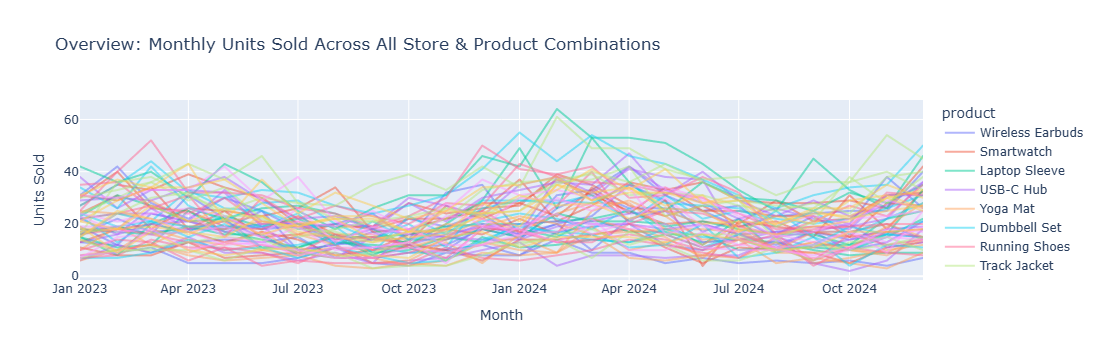

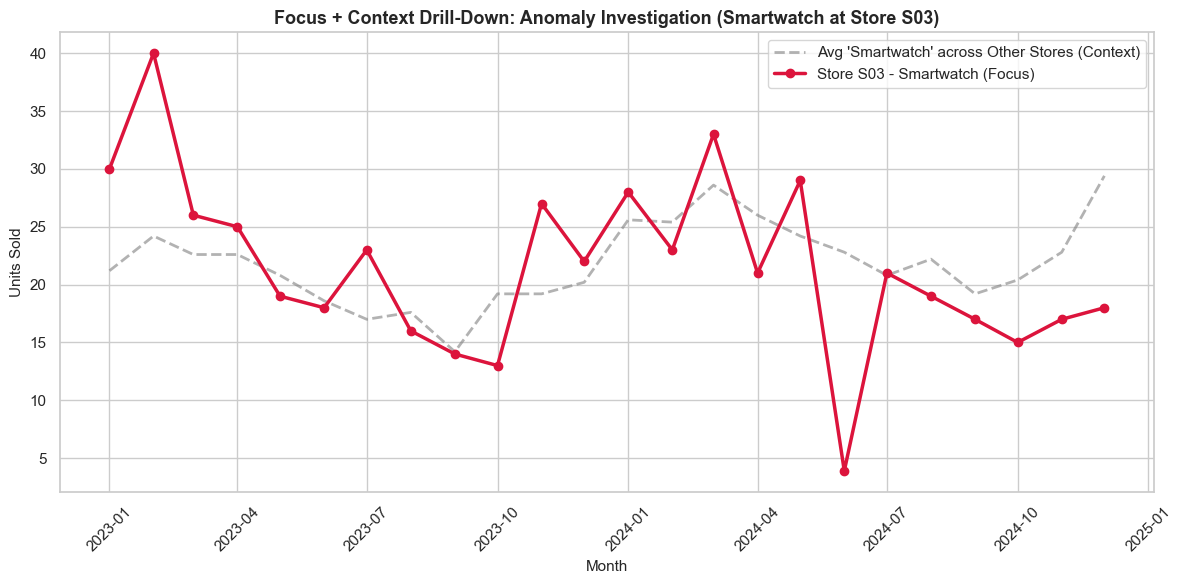

In [9]:
# --- TODO 1: Interactive Overview Plotly Line Chart ---
fig_overview = px.line(
    sales_df,
    x="month",
    y="units_sold",
    color="product",
    line_group="store_id",
    hover_data={"store_id": True, "product": True, "units_sold": True, "month": "|%B %Y"},
    title="Overview: Monthly Units Sold Across All Store & Product Combinations",
    labels={"units_sold": "Units Sold", "month": "Month"}
)
fig_overview.update_traces(opacity=0.5)
fig_overview.show()

# --- TODO 2: Focus + Context Line Chart ---
# Focus: The specific anomalous series (S03 - Smartwatch)
focus_df = sales_df[(sales_df["store_id"] == anomalous_store) & (sales_df["product"] == anomalous_product)]

# Context: Average trend of the same product across ALL OTHER stores
context_df = (
    sales_df[(sales_df["store_id"] != anomalous_store) & (sales_df["product"] == anomalous_product)]
    .groupby("month", as_index=False)["units_sold"]
    .mean()
)

plt.figure(figsize=(12, 6))

# Context line (Faint gray)
plt.plot(
    context_df["month"],
    context_df["units_sold"],
    color="gray",
    linestyle="--",
    linewidth=2,
    alpha=0.6,
    label=f"Avg '{anomalous_product}' across Other Stores (Context)"
)

# Focus line (Highlighted crimson)
plt.plot(
    focus_df["month"],
    focus_df["units_sold"],
    color="crimson",
    marker="o",
    linewidth=2.5,
    label=f"Store {anomalous_store} - {anomalous_product} (Focus)"
)

plt.title(
    f"Focus + Context Drill-Down: Anomaly Investigation ({anomalous_product} at Store {anomalous_store})",
    fontsize=13,
    fontweight="bold"
)
plt.xlabel("Month", fontsize=11)
plt.ylabel("Units Sold", fontsize=11)
plt.xticks(rotation=45)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()



**Reflection:** Which interaction-cost tier (eye fixation / hover / click-to-open panel / window
replacement) did you use to first *spot* the anomaly, and which did you use to *investigate* it? Was
using two different tiers the right call, per the lecture's design rule?

I used eye fixation / hover (the lowest tier in the interaction-cost hierarchy) on the overview chart to spot the outlier line and reveal its identity without leaving the overview. To deeply investigate the dip, I moved to a focus+context inline chart where the anomalous line is overlaid directly against the average benchmark for that product. Using two tiers was the right call according to the lecture design rules because using cheap epistemic actions for initial discovery minimizes context switches, while preserving context during the detailed drill-down avoids high-cost window replacement and cognitive disconnect.



## Task 5 — Table Lens: A Scannable Product Performance Table

**Real-world usage:** A manager wants a single table listing every product's total revenue, total
profit, and average rating across all stores — but a plain spreadsheet of 10 rows x many numeric
columns is still hard to compare at a glance across all three metrics simultaneously.

**Why this technique:** Table Lens (Slide 27) maps numeric columns to in-cell bars, so magnitude
differences are visible pre-attentively while the table stays sortable/readable as text.

### Your task
1. Build a summary DataFrame: one row per `product`, columns for total `revenue`, total `profit`, and
   mean `avg_rating`.
2. Sort it by total revenue, descending.
3. Style it as a Table Lens using `.style.bar(...)` — a different bar color per numeric column, as in
   the Demo notebook — and add a meaningful `.set_caption(...)`.
4. Below the table, add **one more cell**: sort the *same* summary table by `profit` instead of
   `revenue`, and re-render the styled table. Do the top rows change order? Note what that tells a
   manager about revenue vs. profitability.


In [10]:

product_summary = (
    sales_df.groupby("product", as_index=False)
    .agg({"revenue": "sum", "profit": "sum", "avg_rating": "mean"})
    .round({"revenue": 2, "profit": 2, "avg_rating": 2})
)


summary_by_revenue = product_summary.sort_values(
    by="revenue", ascending=False
).reset_index(drop=True)

styled_revenue_table = (
    summary_by_revenue.style.bar(
        subset=["revenue"], color="#5fba7d", vmin=0
    )  # Green for revenue
    .bar(subset=["profit"], color="#4c72b0", vmin=0)  # Blue for profit
    .bar(
        subset=["avg_rating"], color="#e15759", vmin=1, vmax=5
    )  # Coral for rating (scale 1-5)
    .format(
        {"revenue": "₹{:,.2f}", "profit": "₹{:,.2f}", "avg_rating": "{:.2f}"}
    )
    .set_caption(
        "<b>Table Lens: Product Performance Summary (Sorted by Revenue)</b>"
    )
)

display(styled_revenue_table)



,product,revenue,profit,avg_rating
0,Smartwatch,"₹15,706,358.10","₹3,881,507.11",4.09
1,Air Fryer,"₹10,901,274.00","₹2,593,731.37",4.04
2,Running Shoes,"₹9,688,731.00","₹2,303,074.98",4.10
3,Dumbbell Set,"₹7,796,880.00","₹1,829,126.92",4.11
4,Blender,"₹7,648,773.00","₹1,860,308.56",4.04
5,Track Jacket,"₹6,992,502.00","₹1,610,283.09",4.13
6,USB-C Hub,"₹3,842,442.00","₹907,435.12",4.09
7,Wireless Earbuds,"₹3,769,985.00","₹890,553.52",4.09
8,Laptop Sleeve,"₹2,801,284.00","₹664,357.72",4.08
9,Yoga Mat,"₹1,560,447.00","₹370,892.40",4.07


In [11]:

summary_by_profit = product_summary.sort_values(
    by="profit", ascending=False
).reset_index(drop=True)

styled_profit_table = (
    summary_by_profit.style.bar(subset=["revenue"], color="#5fba7d", vmin=0)
    .bar(subset=["profit"], color="#4c72b0", vmin=0)
    .bar(subset=["avg_rating"], color="#e15759", vmin=1, vmax=5)
    .format(
        {"revenue": "₹{:,.2f}", "profit": "₹{:,.2f}", "avg_rating": "{:.2f}"}
    )
    .set_caption(
        "<b>Table Lens: Product Performance Summary (Sorted by Profit)</b>"
    )
)

display(styled_profit_table)

,product,revenue,profit,avg_rating
0,Smartwatch,"₹15,706,358.10","₹3,881,507.11",4.09
1,Air Fryer,"₹10,901,274.00","₹2,593,731.37",4.04
2,Running Shoes,"₹9,688,731.00","₹2,303,074.98",4.10
3,Blender,"₹7,648,773.00","₹1,860,308.56",4.04
4,Dumbbell Set,"₹7,796,880.00","₹1,829,126.92",4.11
5,Track Jacket,"₹6,992,502.00","₹1,610,283.09",4.13
6,USB-C Hub,"₹3,842,442.00","₹907,435.12",4.09
7,Wireless Earbuds,"₹3,769,985.00","₹890,553.52",4.09
8,Laptop Sleeve,"₹2,801,284.00","₹664,357.72",4.08
9,Yoga Mat,"₹1,560,447.00","₹370,892.40",4.07



**Your observation (revenue-sorted vs profit-sorted top rows):**

Yes, the top rows change order when re-sorting by profit. High revenue does not directly guarantee high profitability—certain top-selling products yield lower net profit due to squeezed profit margins. This instantly alerts managers that prioritizing inventory or marketing based purely on top-line revenue could divert focus away from lower-revenue items that generate higher overall net profit margin.


## Task 6 — Assemble a Single-Screen Monitoring Dashboard (open-ended)

**Real-world usage:** All three complaints at once. UrbanCart wants a **single screen** a regional
manager can glance at every morning — no interaction required to read the headline state, per the
Dashboard Patterns slide (Slide 28): critical indicators visible at a glance, with a peripheral-tier
alert that uses color (not subtlety) to flag something that needs attention.

### Your task
Build a 2x2 dashboard (`plt.subplots(2, 2, ...)`) with:

1. **Top-left — KPI summary panel** (`ax.axis("off")` + `ax.text(...)`): total revenue, total profit,
   overall average rating, and number of active stores, computed from `sales_df`.
2. **Top-right — mid-term analysis panel**: revenue by `region` (bar chart).
3. **Bottom-left — long-term trend panel**: total revenue by `month`, across all stores (line chart).
4. **Bottom-right — peripheral alert panel**: check whether **any** `(store_id, product)` pair has a
   month where `units_sold` fell below **25% of its own median** for that pair (this is the anomaly
   you found in Task 4, but write the check generically so it would catch *any* such case, not just
   the one you already know about). Show a red "ALERT — N issue(s) found" indicator if any exist, or
   a green "OK" indicator if not.

This task is intentionally the least scaffolded — you decide the exact `groupby` calls, panel layout
details, and styling. Reuse patterns from Tasks 1-5 and the Demo notebook where they fit, but write
the logic yourself.


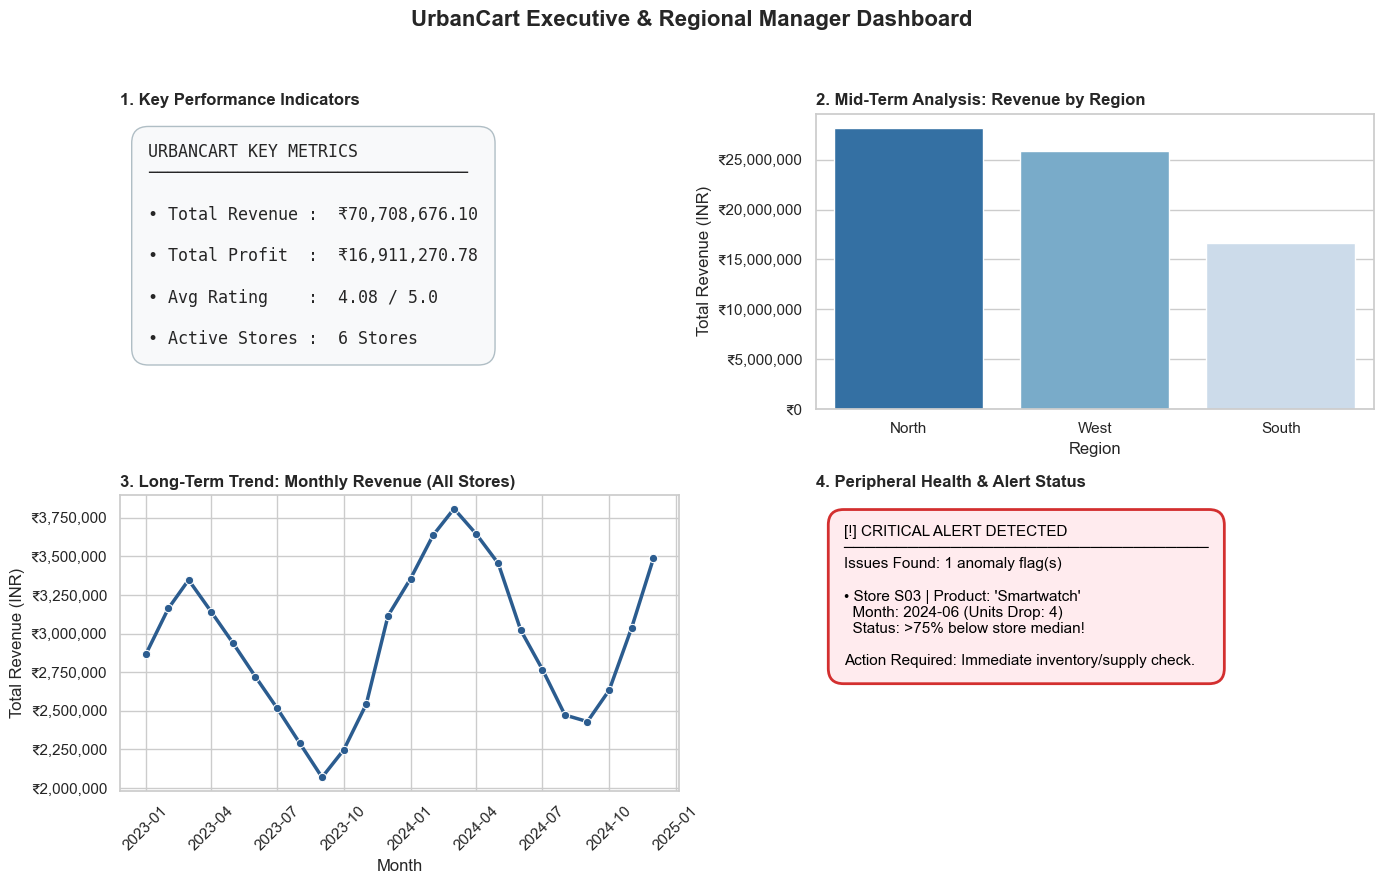

In [15]:
# Create 2x2 dashboard layout
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Panel 1: KPI Summary (Top-Left)

ax1 = axes[0, 0]
ax1.axis("off")

# Calculate KPIs
total_revenue = sales_df["revenue"].sum()
total_profit = sales_df["profit"].sum()
overall_rating = sales_df["avg_rating"].mean()
active_stores = sales_df["store_id"].nunique()

kpi_text = (
    f"URBANCART KEY METRICS\n"
    f"{'─' * 32}\n\n"
    f"• Total Revenue :  ₹{total_revenue:,.2f}\n\n"
    f"• Total Profit  :  ₹{total_profit:,.2f}\n\n"
    f"• Avg Rating    :  {overall_rating:.2f} / 5.0\n\n"
    f"• Active Stores :  {active_stores} Stores"
)

ax1.text(
    0.05,
    0.90,
    kpi_text,
    fontsize=12,
    fontfamily="monospace",
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=1.0", facecolor="#f8f9fa", edgecolor="#b0bec5"
    ),
)
ax1.set_title(
    "1. Key Performance Indicators", fontsize=12, fontweight="bold", loc="left"
)


# Panel 2: Revenue by Region (Top-Right)
ax2 = axes[0, 1]
region_revenue = (
    sales_df.groupby("region", as_index=False)["revenue"]
    .sum()
    .sort_values(by="revenue", ascending=False)
)

sns.barplot(
    data=region_revenue,
    x="region",
    y="revenue",
    palette="Blues_r",
    ax=ax2,
    hue="region",
    legend=False,
)
ax2.set_title(
    "2. Mid-Term Analysis: Revenue by Region",
    fontsize=12,
    fontweight="bold",
    loc="left",
)
ax2.set_xlabel("Region")
ax2.set_ylabel("Total Revenue (INR)")
ax2.yaxis.set_major_formatter("₹{x:,.0f}")


# Panel 3: Monthly Revenue Trend (Bottom-Left)
ax3 = axes[1, 0]
monthly_revenue = sales_df.groupby("month", as_index=False)["revenue"].sum()

sns.lineplot(
    data=monthly_revenue,
    x="month",
    y="revenue",
    marker="o",
    color="#2b5c8f",
    linewidth=2.5,
    ax=ax3,
)
ax3.set_title(
    "3. Long-Term Trend: Monthly Revenue (All Stores)",
    fontsize=12,
    fontweight="bold",
    loc="left",
)
ax3.set_xlabel("Month")
ax3.set_ylabel("Total Revenue (INR)")
ax3.yaxis.set_major_formatter("₹{x:,.0f}")
ax3.tick_params(axis="x", rotation=45)

# Panel 4: Peripheral Alert Panel (Bottom-Right)
ax4 = axes[1, 1]
ax4.axis("off")


# Generic anomaly check avoiding pandas groupby.apply deprecation
def detect_anomalies(df):
    anomalies = []
    for (store, prod), group in df.groupby(["store_id", "product"]):
        median_val = group["units_sold"].median()
        if median_val == 0:
            continue
        drop_mask = group["units_sold"] < (0.25 * median_val)
        if drop_mask.any():
            drop_months = (
                group.loc[drop_mask, "month"].dt.strftime("%Y-%m").tolist()
            )
            vals = group.loc[drop_mask, "units_sold"].values
            anomalies.append((store, prod, drop_months, vals))
    return anomalies


anomalies_found = detect_anomalies(sales_df)

if anomalies_found:
    alert_box_color = "#ffebee"  # Soft red background
    alert_border_color = "#d32f2f"  # Red border
    alert_text = (
        f"[!] CRITICAL ALERT DETECTED\n"
        f"{'─' * 34}\n"
        f"Issues Found: {len(anomalies_found)} anomaly flag(s)\n\n"
    )
    for store, prod, m_list, vals in anomalies_found:
        alert_text += (
            f"• Store {store} | Product: '{prod}'\n"
            f"  Month: {m_list[0]} (Units Drop: {vals[0]:.0f})\n"
            f"  Status: >75% below store median!\n\n"
        )
    alert_text += "Action Required: Immediate inventory/supply check."
else:
    alert_box_color = "#e8f5e9"  # Soft green background
    alert_border_color = "#388e3c"  # Green border
    alert_text = (
        f"[OK] SYSTEM STATUS: NORMAL\n"
        f"{'─' * 34}\n\n"
        f"• All products across all 6 stores are\n"
        f"  performing within normal median thresholds.\n\n"
        f"• No critical drops detected."
    )

ax4.text(
    0.05,
    0.90,
    alert_text,
    fontsize=11,
    fontfamily="sans-serif",
    verticalalignment="top",
    color="#000000",
    bbox=dict(
        boxstyle="round,pad=1.0",
        facecolor=alert_box_color,
        edgecolor=alert_border_color,
        linewidth=2,
    ),
)
ax4.set_title(
    "4. Peripheral Health & Alert Status",
    fontsize=12,
    fontweight="bold",
    loc="left",
)

# Global Dashboard Title and Layout
fig.suptitle(
    "UrbanCart Executive & Regional Manager Dashboard",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Reflection

Answer briefly, referring back to the three manager complaints from the scenario intro:

1. Which single technique from this activity do you think gives UrbanCart's managers the *biggest*
   time saving, and why?
2. Which technique was hardest to implement well, and what design trade-off (from the lecture) did you
   have to think about while building it?
3. If you had to add **one more** interaction technique from the lecture that this activity didn't
   cover (e.g. geometric fisheye, magic lens, network zooming, model-based planning), where in this
   retail scenario would it actually be useful, and why?


   

*1.Coordinated Multiple Views with Cross-View Brushing (Task 3) provides the largest time saving. It addresses Complaint #2 directly by eliminating the constant page-flipping inherent in static PDF reports. Selecting a single store highlights its global position while dynamically updating category breakdowns and trendlines simultaneously, reducing the cognitive load of cross-referencing disjointed charts.*


*2.Focus + Context Drill-Down (Task 4) was the hardest to implement effectively. The primary design trade-off involves balancing visual clarity with context preservation. Displaying granular focus details alongside global context on a single screen without cluttering the view requires carefully tuning visual encoding choices (such as muted gray lines and high-contrast focus colors) to avoid confusing the user with excessive overlapping elements.*


*3.A Magic Lens (Fisheye / Inspection Lens) would be useful in this retail scenario. Placed over dense scatter plots or time-series line charts, a Magic Lens allows managers to temporarily magnify localized data clusters—such as zooming in on a specific month's daily transaction spikes—without disrupting the surrounding visual timeline or losing overall structural context.*
